# Library Analysis

## Objective

Analyze the mutation spectrum of the Pikh-1 library to realistically parameterize the epPCR simulation.

First, we create a dataframe of aligned reads. I'm repurposing a script from a different project here that uses the alignparse package to align the merged reads to the WT amplicon, then returns a dataframe with columns "library" and "sample" for initializing the subsequent CodonVariantTable, the full sequence, and the mutations.

In [1]:
from pathlib import Path

from scripts.align_and_parse import construct_master_alignment_df

reads_df = construct_master_alignment_df(
    amplicon_file="configs/pikh1_amplicon.gb",
    alignparse_config="configs/alignparse_config.yaml",
    locus_name="pikh1_amplicon",
    merged_reads_dir=Path("seq_data")
)

reads_df


Processing lib...
    Aligning reads from seq_data/lib_merged.fastq to configs/pikh1_amplicon.gb...
    Parsing alignment from /tmp/tmp_o_xzkzb.sam...
    Adding mutation info columns for locus pikh1_amplicon...
    Expanding mutations to full sequences for lib...
Combining all sample DataFrames into master DataFrame...
Total aligned reads across all samples: 360010


,library,sample,sequence,gene_mutations,n_subs,n_indels
0,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,T65C A160C A229G,3,0
1,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGGGGAGGCTCTGGTG...,T33G G61A A64G T216C,4,0
2,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,A163G,1,0
3,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,T57C A187G T215C,3,0
4,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,A128G,1,0
...,...,...,...,...,...,...
360005,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,T93C,1,0
360006,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,C83T T138A T172C C224T G232A,5,0
360007,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,A108G A129G,2,0
360008,library,lib,GTTCCAGACTACGCTGTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,A16G A95G T137C T170C G190A,5,0


Let's calculate the average number of substitutions per sequence and take a look at the distribution.

In [2]:
reads_df.n_subs.mean()

np.float64(3.4306852587428125)

In [3]:
import plotly.express as px

fig = px.histogram(reads_df, 'n_subs')
fig.show()

It looks like a pretty clear Poisson distribution with an average of 3.43 mutations per sequence.

Now we make the variant table which uses CodonVariantTable from dms_variants package. It uses the full sequence as the "barcode" for a unique variant. While not necessary for parameterizing epPCR, I haven't done the full analysis for the sequence-as-barcode scheme on the library yet.

In [4]:
from scripts.construct_variant_table import construct_variant_table

variant_table = construct_variant_table(
    aligned_reads_df=reads_df,
    wt_dna_file='configs/pikh1_dna_seq.fasta'
)

Constructing variant table...


In [5]:
variant_table.variant_count_df.sort_values('count', ascending=False)

,library,sample,barcode,count,variant_call_support,codon_substitutions,aa_substitutions,n_codon_substitutions,n_aa_substitutions
0,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,33897,1,AAG55GAG,K55E,1,1
1,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,934,1,AAA9AGA ATT57ATC,K9R,2,1
2,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,827,1,GTT25GCT GGT30GAT AAG55GAG AAG62AGG,V25A G30D K55E K62R,4,4
3,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,823,1,ATG12AGG TCT73CCT,M12R S73P,2,2
4,library,lib,GTTCCAGACTACGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,812,1,ATG22AGG GAT32GTT GTT72GTC,M22R D32V,3,2
...,...,...,...,...,...,...,...,...,...
151686,library,lib,TTTCCAGACTACGGTCTGCAGGCTAGGGGTGGAGGAGGCTCTGGTG...,1,1,GGT1TGT AAA5AGA AAA9AAG GCT21GCC GAT39AGT ATT5...,G1C K5R D39S I57V K77E,7,5
151687,library,lib,TTTCCAGACTACGGTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,1,1,GGT1TGT AAG3GAG AAA5AGA ATC51ACC GAC52GGC,G1C K3E K5R I51T D52G,5,5
151688,library,lib,TTTCCAGACTACGGTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,1,1,GGT1TGT AAA5AGA,G1C K5R,2,2
151689,library,lib,TTTCCAGACTAGGCTCTGCAGGCTAGTGGTGGAGGAGGCTCTGGTG...,1,1,GGT1TGT CAA4CAG GTT25ATT GAA68GGA TCT73CCT,G1C V25I E68G S73P,5,4


Interestingly, there's one sequence that has a way higher count than everything else for some reason. It's a full 10% of the library.

In [3]:
variant_table.avgCountsPerVariant()

,library,sample,avg_counts_per_variant
0,library,lib,2.373312


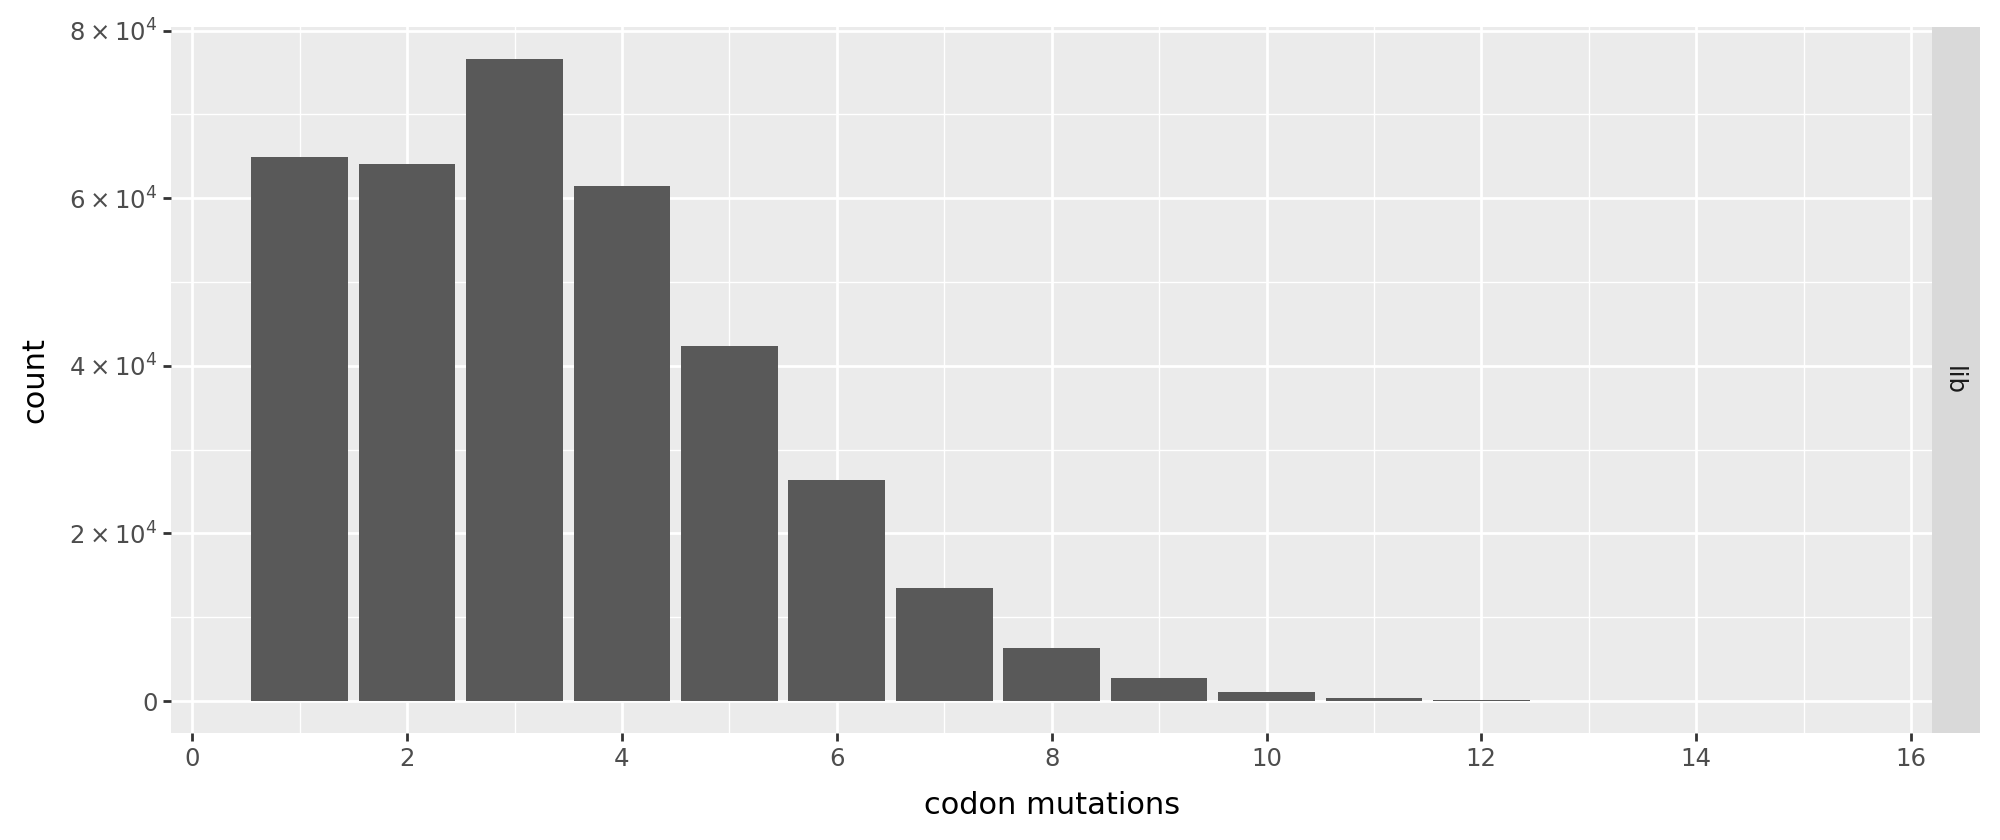

In [4]:
variant_table.plotNumMutsHistogram('codon', libraries='all', samples='all',widthscale=4, heightscale=2)

/home/oscar/miniconda3/envs/variant-effect-prediction/lib/python3.12/site-packages/dms_variants/codonvarianttable.py:2179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/oscar/miniconda3/envs/variant-effect-prediction/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'color' aesthetic. Make sure you have mapped a variable to it


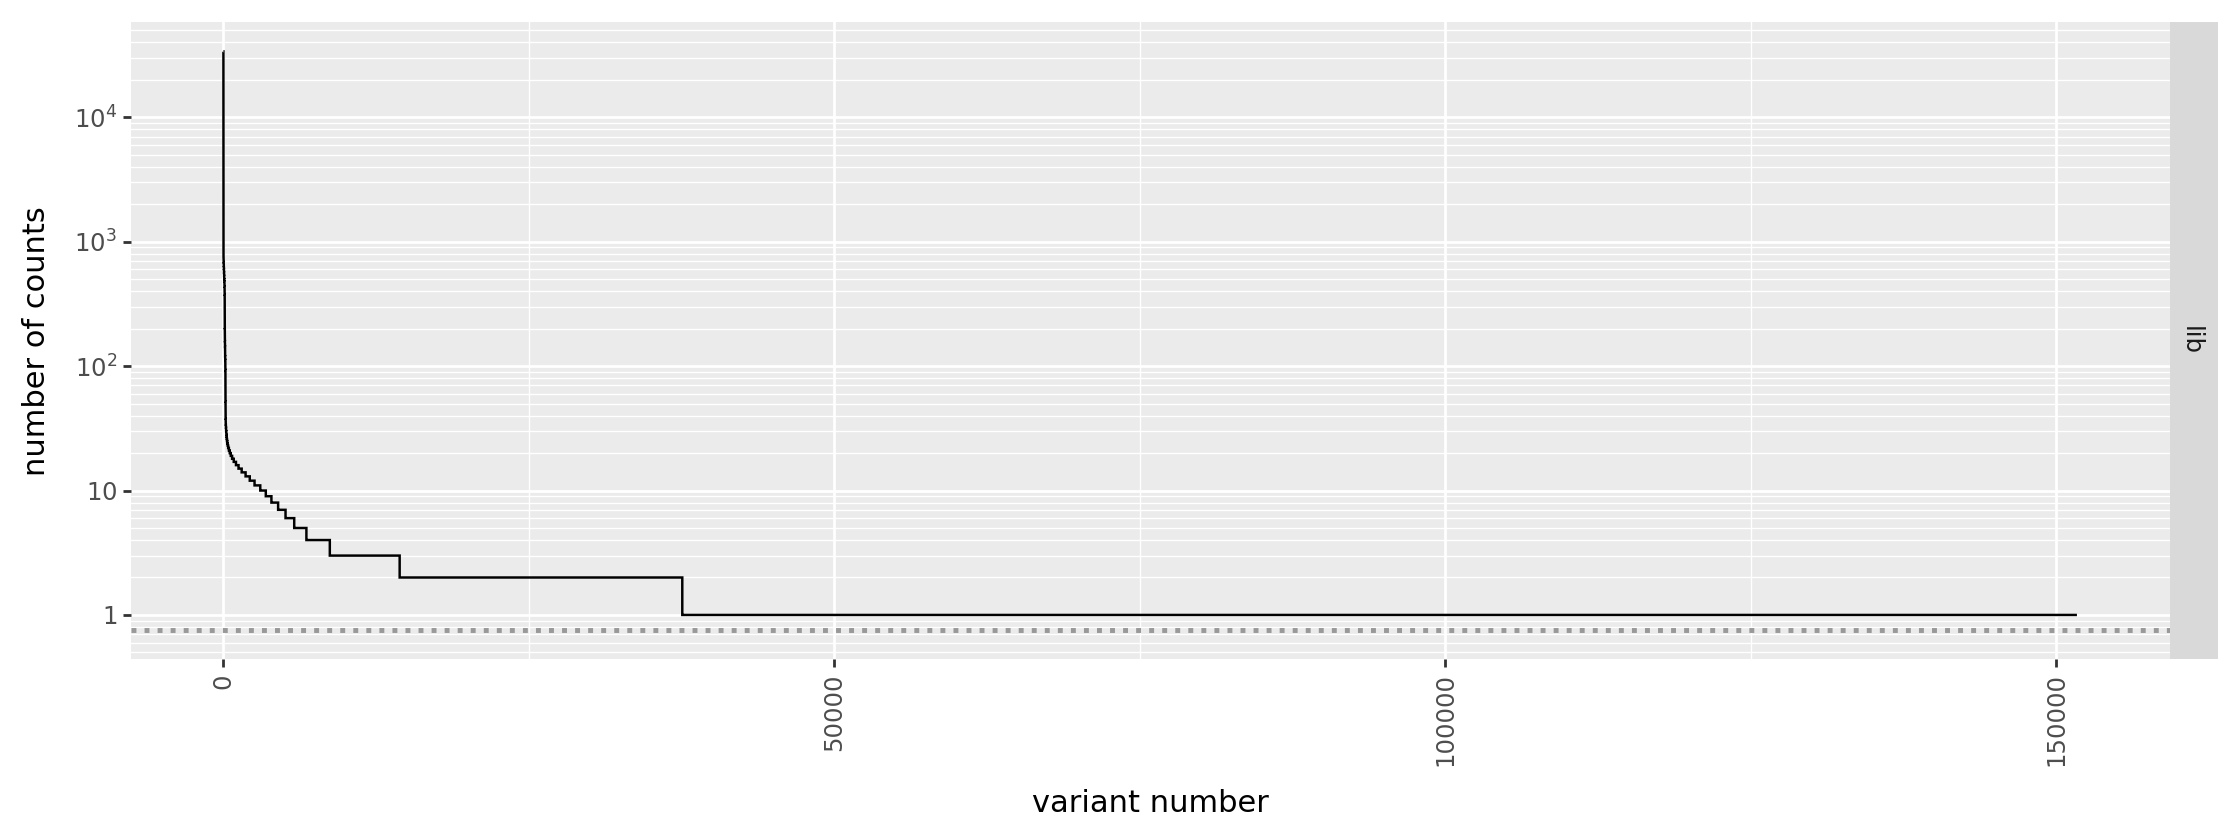

In [5]:
variant_table.plotCountsPerVariant(ystat='count',widthscale=4, heightscale=2)

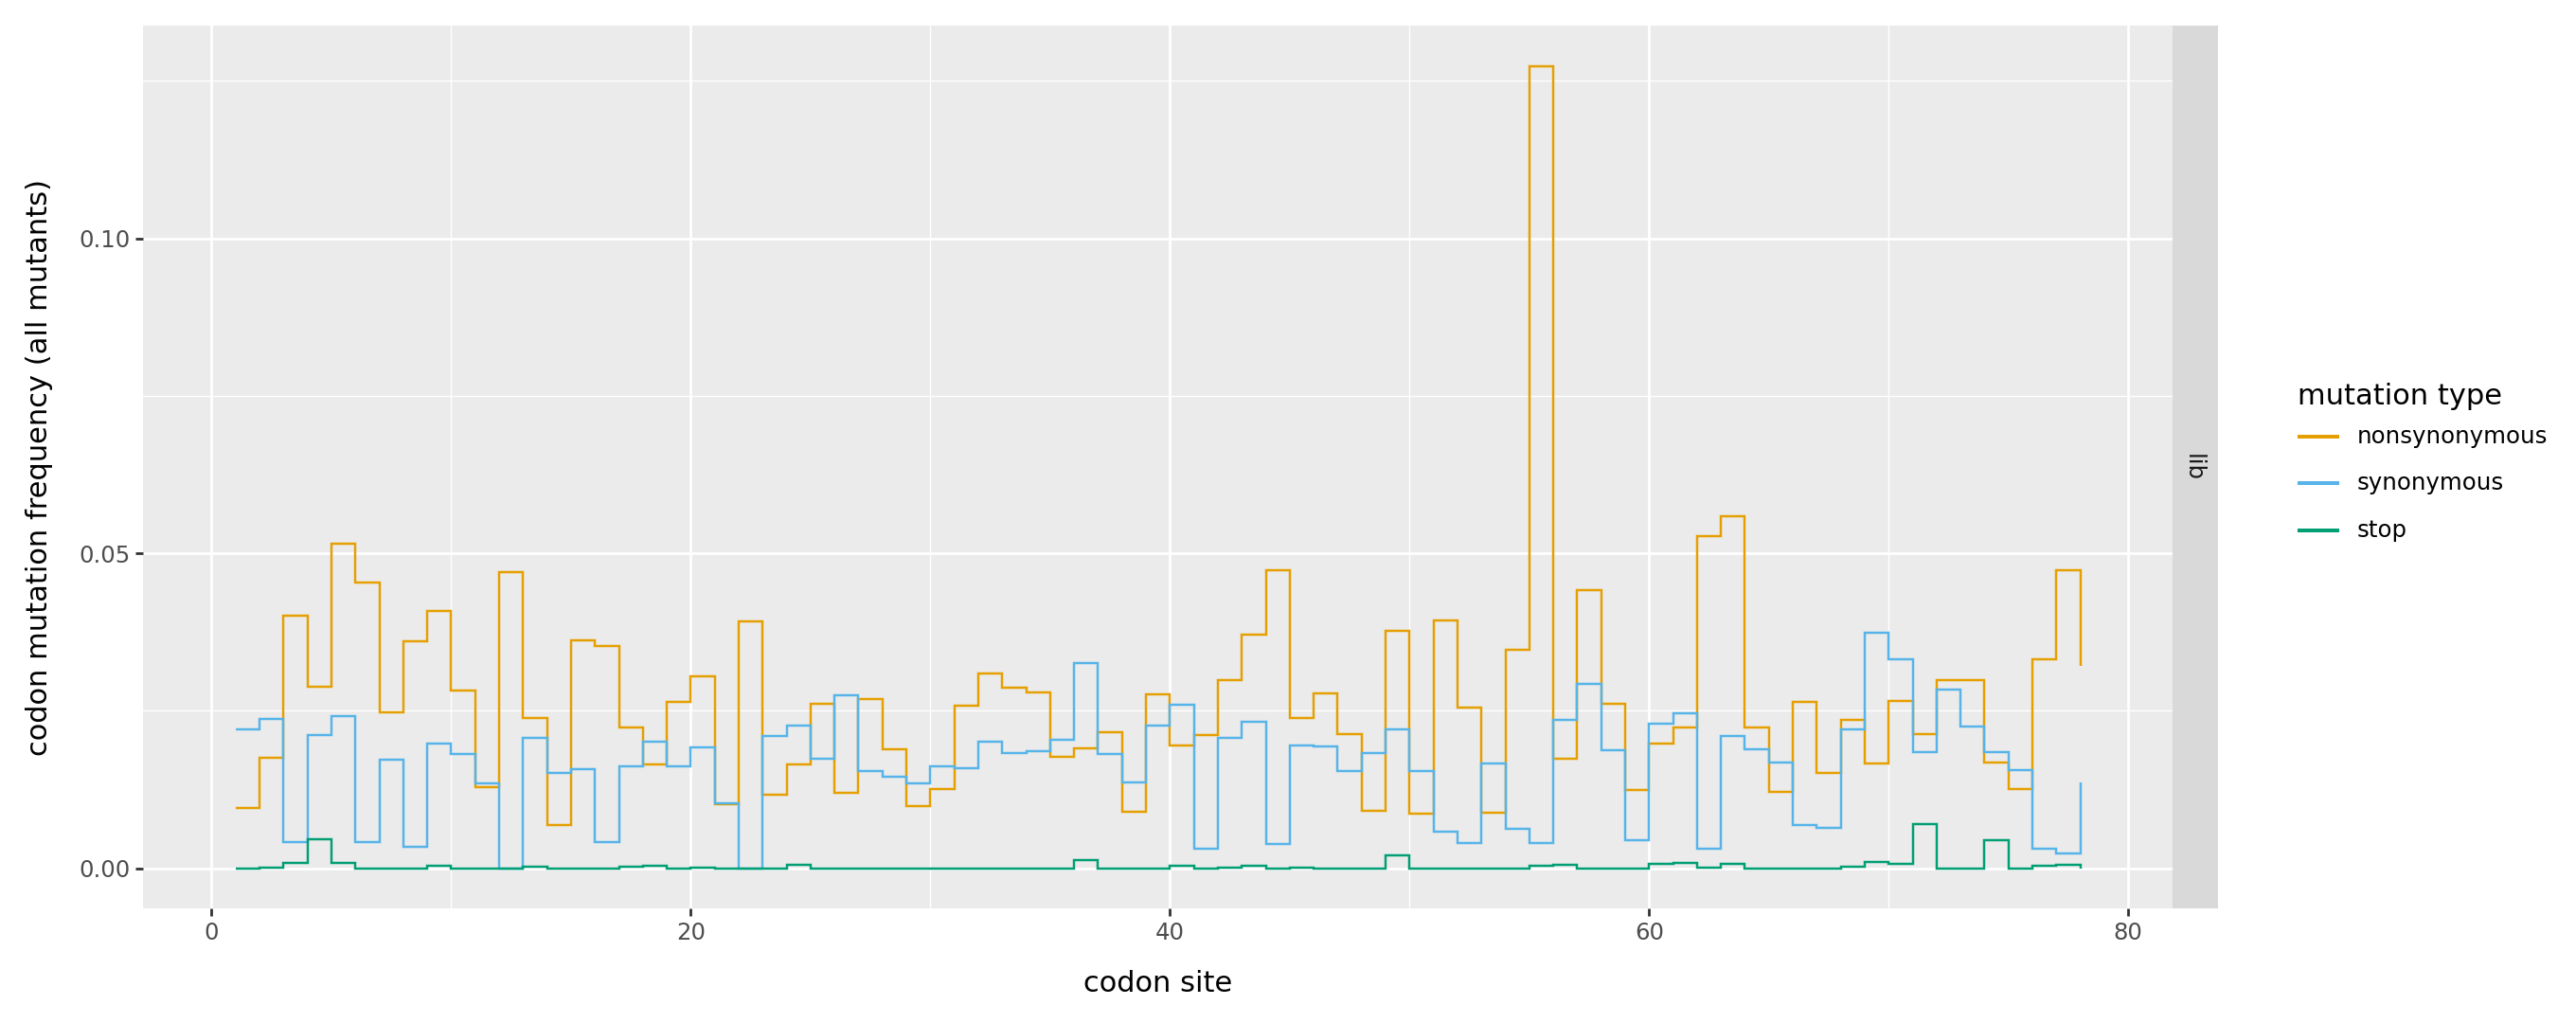

In [6]:
variant_table.plotMutFreqs('all','codon', widthscale=4, heightscale=3)

Now we'll look at the heatmap. There's two ways to do with. The default has argument samples="all", which will sum the counts for each mutation and divide by total reads in the sample. If you set samples=None, it will count the number of unique barcodes containing each mutation, and divide by the total number of unique barcodes in the library. 

Keep in mind that, in my case, barcodes are unique DNA sequences.

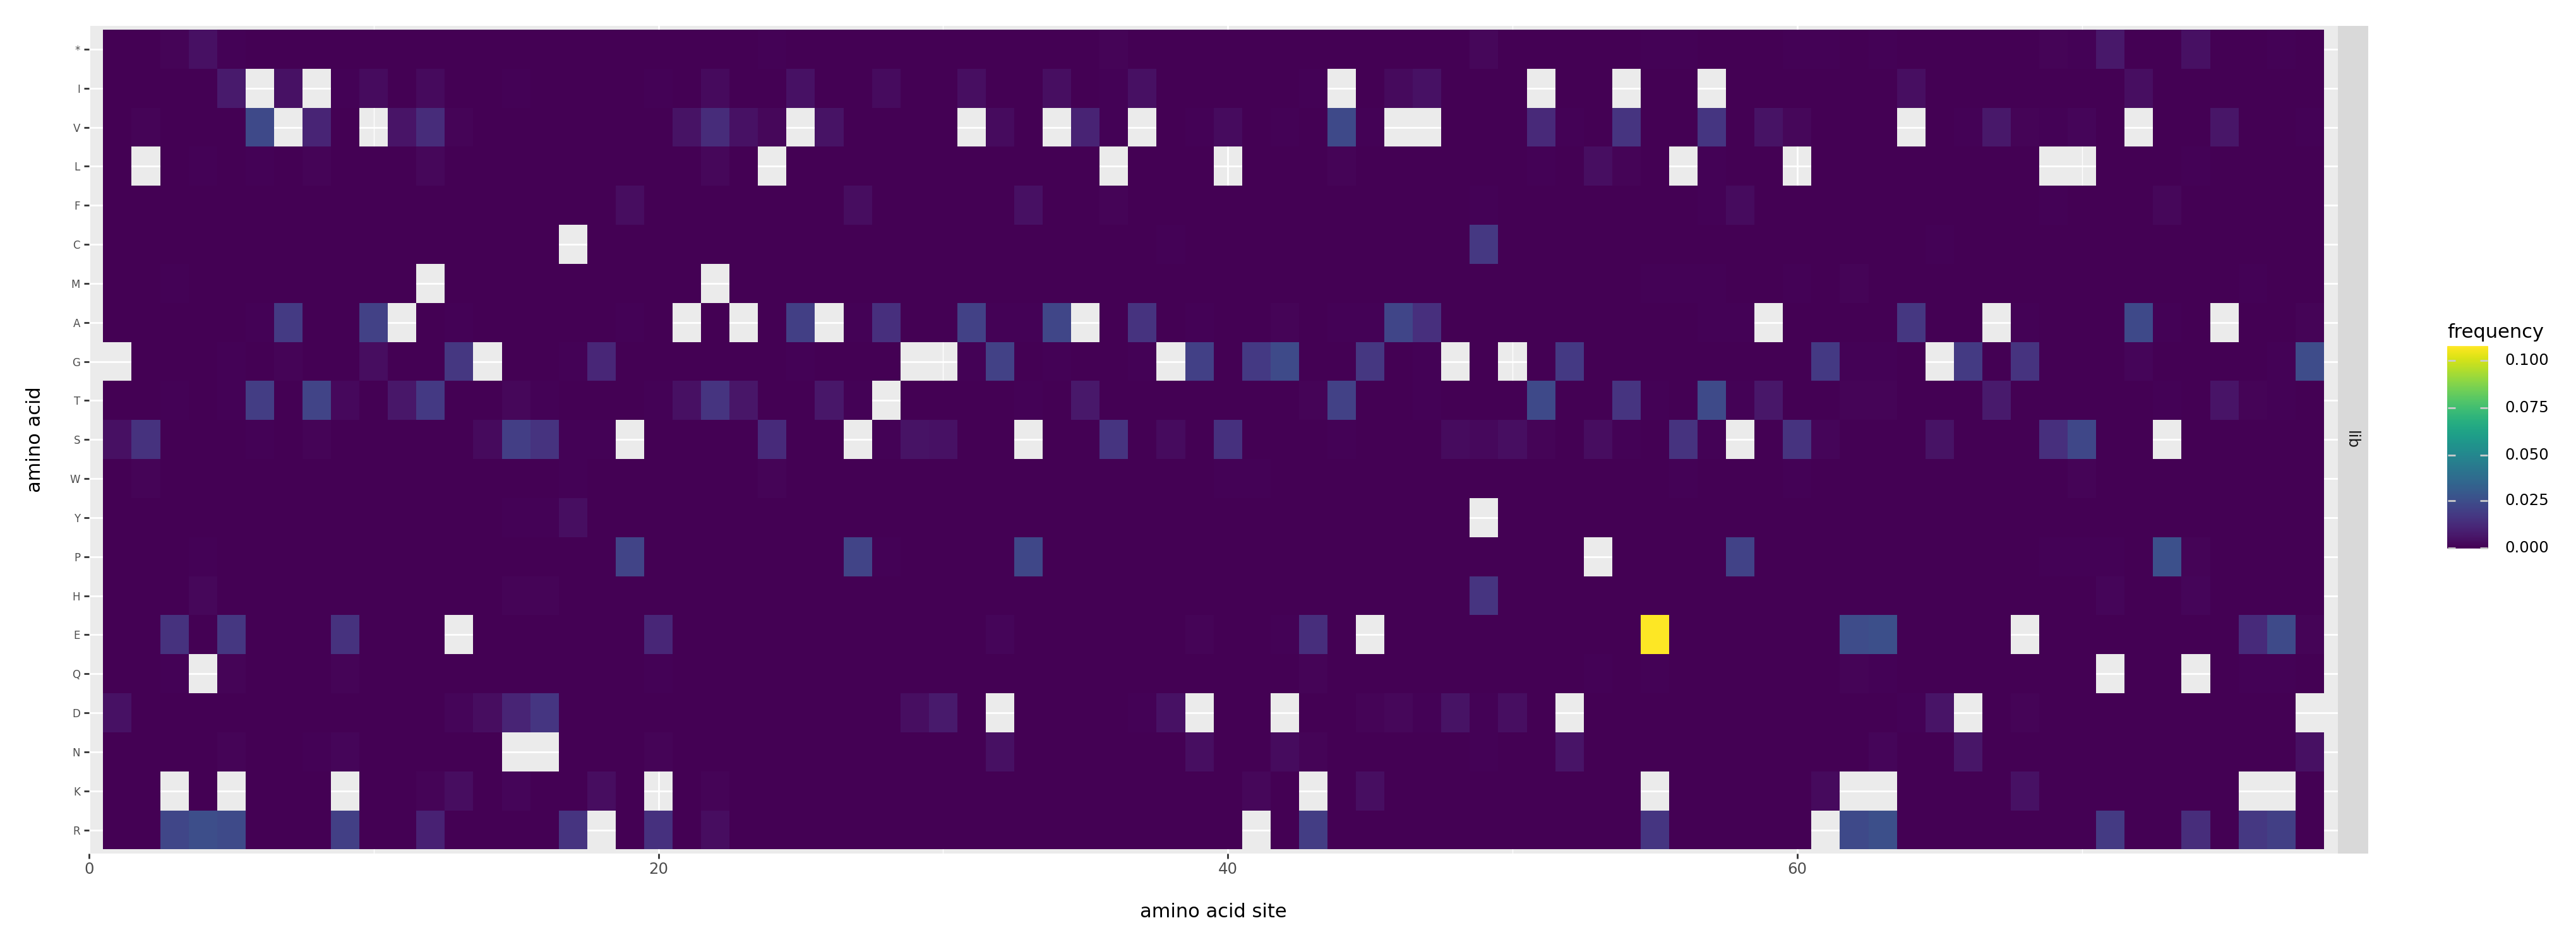

In [7]:
variant_table.plotMutHeatmap('all', 'aa', count_or_frequency='frequency', widthscale=4, heightscale=3)


With samples="all", that one mutant comprising with 10% of the reads dominates.

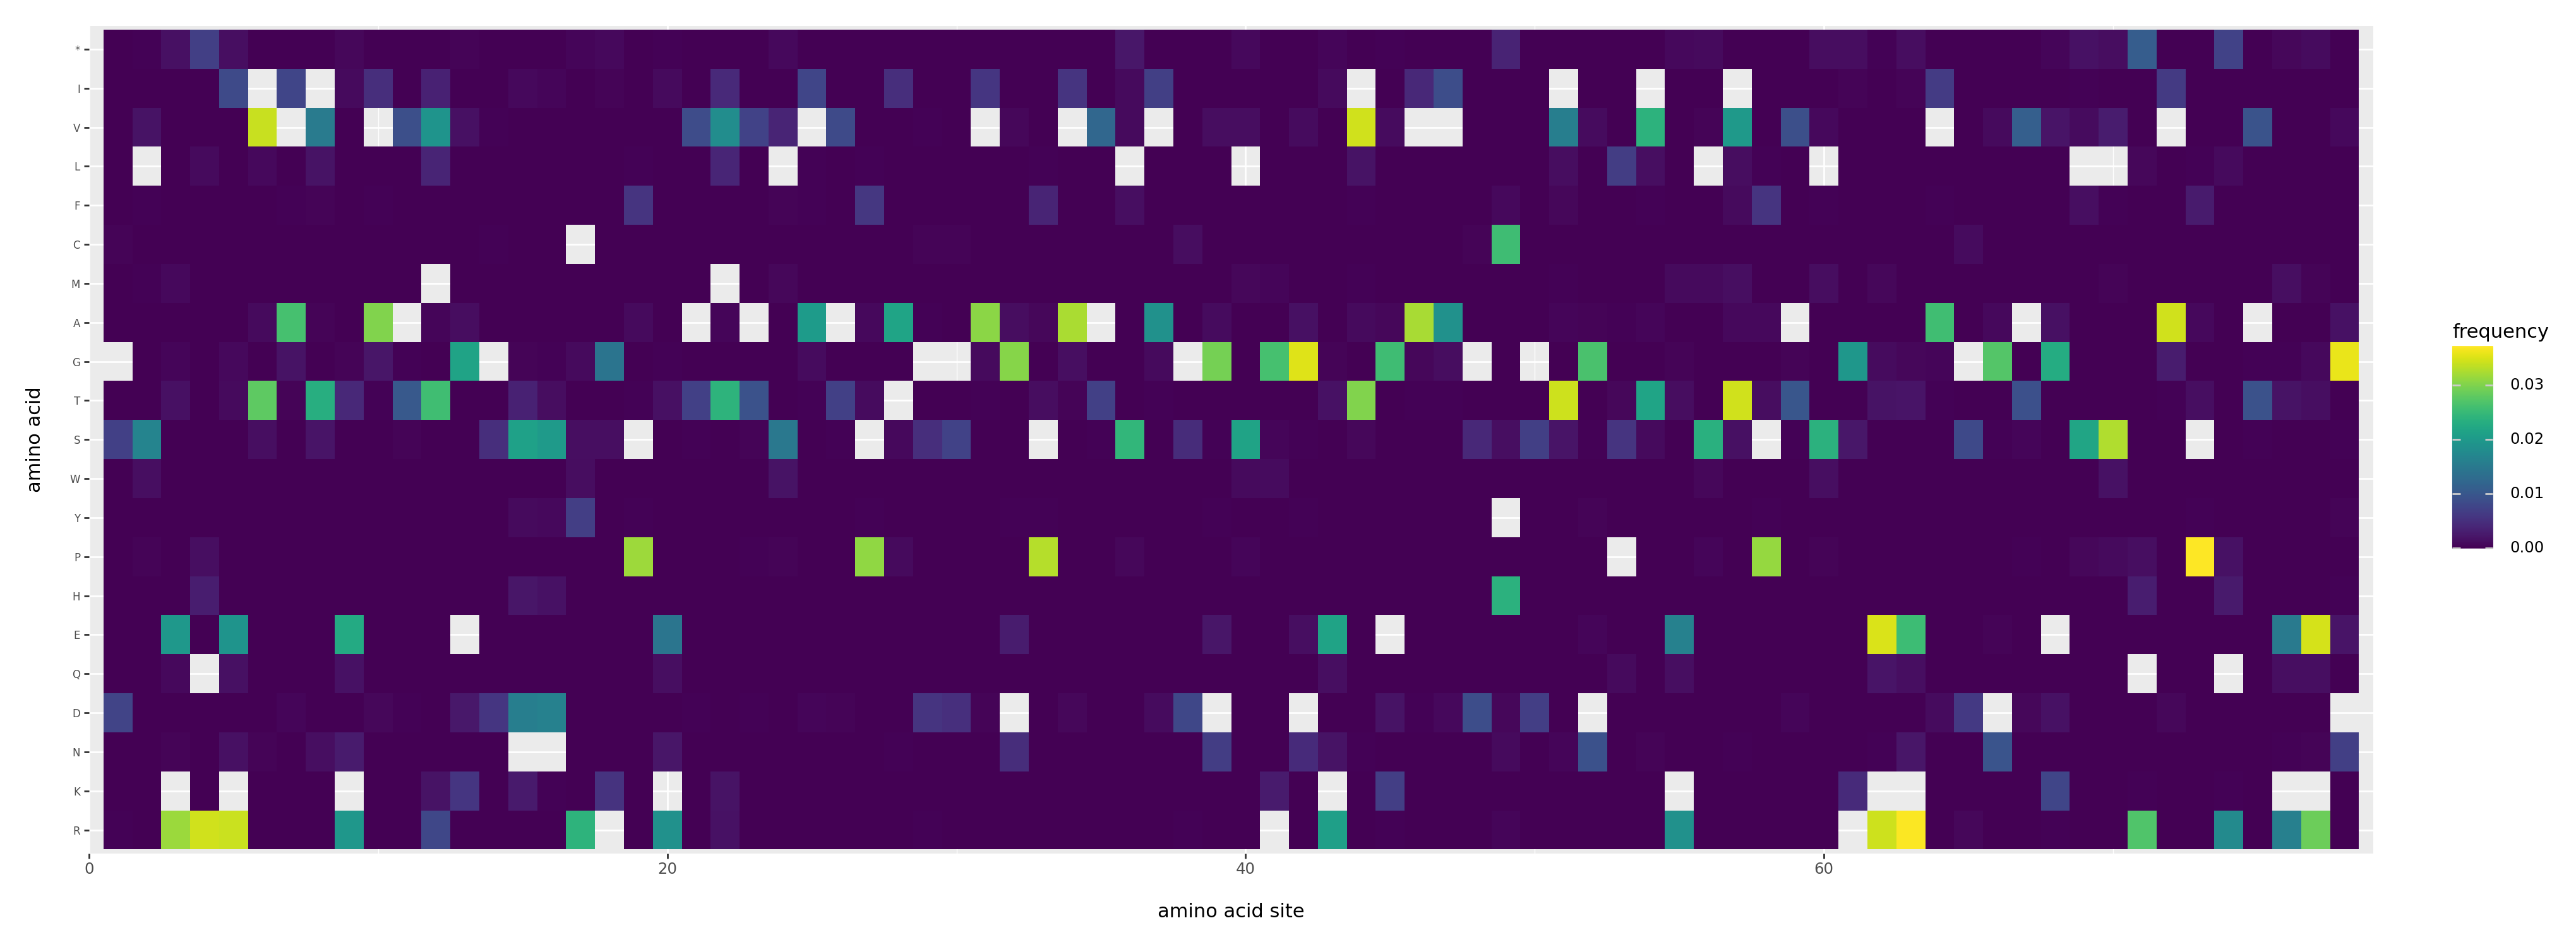

In [48]:
variant_table.plotMutHeatmap('all', 'aa', count_or_frequency='frequency', widthscale=4, heightscale=3, samples=None)

With samples=None, it's pretty much the same thing, but leveled out a bit more since that one sequence that was counted 30k times is now only counted once.

Now we should look at nucleotide mutational bias to actually get the parameters for our epPCR simulation. First, we turn the nucleotide mutations into lists, then "explode" them, so that each mutation is its own item in the list.

In [8]:
all_nt_muts = reads_df['gene_mutations'].str.split().explode().dropna()
all_nt_muts

0          T65C
0         A160C
0         A229G
1          T33G
1          G61A
          ...  
360008     A95G
360008    T137C
360008    T170C
360008    G190A
360009     T78C
Name: gene_mutations, Length: 1235081, dtype: object

Now we can group them by mutation type, and count.

In [38]:
def get_mut_type(mut_string):
    return f"{mut_string[0]}>{mut_string[-1]}"

mut_types_series = all_nt_muts.apply(get_mut_type)

mut_counts_df = mut_types_series.value_counts().reset_index()
mut_counts_df.columns = ['mutation', 'count']
mut_counts_df = mut_counts_df.sort_values('mutation').reset_index(drop=True)

mut_counts_df

,mutation,count
0,A>C,21408
1,A>G,457612
2,A>T,14748
3,C>A,1810
4,C>G,891
5,C>T,53886
6,G>A,101302
7,G>C,1236
8,G>T,3375
9,T>A,12586


To parameterize epPCR, we need to know, given a WT base, what is the probability of being mutated to any of the other bases.

In [ ]:
wts = []
freqs = []

# Calculate frequency as the counts for that mutation / sum of counts with that WT base
for mut in mut_counts_df.iterrows():
    wt = mut[1]['mutation'][0]
    wts.append(wt)
    freq = mut[1]['count'] / sum(mut_counts_df[mut_counts_df.mutation.str.startswith(wt)]['count'])
    freqs.append(freq)

mut_counts_df['mut_freq'] = freqs
mut_counts_df['wt'] = wts
mut_counts_df

,mutation,count,mut_freq,wt
0,A>C,21408,0.043356,A
1,A>G,457612,0.926775,A
2,A>T,14748,0.029868,A
3,C>A,1810,0.031986,C
4,C>G,891,0.015746,C
5,C>T,53886,0.952268,C
6,G>A,101302,0.956464,G
7,G>C,1236,0.011670,G
8,G>T,3375,0.031866,G
9,T>A,12586,0.021745,T


In [42]:
import plotly.express as px

fig = px.bar(mut_counts_df, "mutation", "mut_freq", color='wt')
fig.show()

For an overview of the mutational spectrum, comparing any WT base, here's a plot of just the counts.

In [44]:
import plotly.express as px

fig = px.bar(mut_counts_df, "mutation", "count", color='wt')
fig.show()

Recently, I found that the plasmid isolation and transfer to PCR has the potential to be a bottleneck even worse than the sequencing. Fortunately, there are ways to estimate the lower bound of the underlying library diversity in sequencing data based on the frequency of sequences seen one and sequences seen twice. It's called a [Chao1 estimator](https://onlinelibrary.wiley.com/doi/10.1002/9780470015902.a0026329?msockid=2c17b5ae16986ade30aba31d17006b09), and it has a fairly simple formula:

$$
D_{chao1} = D_{obs} + \frac{f_1^2}{2f_2}
$$

Where $D_{chao1}$ is the lower-bound estimate of underlying library diversity, $D_{obs}$ is the observed diversity $f_1$ is the frequency of singletons, and $f_2$ is the frequency of doubletons.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_chao1(variant_counts):
    """
    variant_counts: A list of integers representing the read count for each unique variant.
    e.g., [1, 1, 1, 2, 5, 1, 100, ...]
    """
    total_reads = sum(variant_counts)
    n_unique = len(variant_counts)
    
    # Calculate Singletons (f1) and Doubletons (f2)
    f1 = variant_counts.count(1)
    f2 = variant_counts.count(2)
    
    print(f"Total Reads: {total_reads}")
    print(f"Unique Variants: {n_unique}")
    print(f"Singletons (F1): {f1}")
    print(f"Doubletons (F2): {f2}")
    
    # Chao1 Estimation (True Library Size)
    chao1 = n_unique + (f1**2 / (2 * f2))
    
    
    print(f"Estimated True Library Size (Chao1): {int(chao1)}")
    print(f"Current Discovery: {n_unique / chao1 * 100:.1f}% of estimated total")

calculate_chao1(list(variant_table.variant_count_df['count']))


Total Reads: 360010
Unique Variants: 151691
Singletons (F1): 114136
Doubletons (F2): 23130
Estimated True Library Size (Chao1): 433295
Current Discovery: 35.0% of estimated total


This confirms that the bottleneck is indeed sequencing, but the plasmid prep isn't far behind, within an order of magnitude of the read counts.